## VERITASKAP STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

veritaskap=pd.read_csv('../stock_data/veritaskap.csv') ## so it can be small letter. This is cool.
veritaskap=veritaskap.drop(columns=['high_price','low_price'])
veritaskap.rename(columns={'trade_date':'date'},inplace=True)
veritaskap['date']=pd.to_datetime(veritaskap['date'])
veritaskap['month']=veritaskap['date'].dt.month
veritaskap['quarter']=veritaskap['date'].dt.quarter
veritaskap['year']=veritaskap['date'].dt.year

veritaskap

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,72296,VERITASKAP,2018-04-16,0.25,0.25,0,2026-04-08T03:03:01.748445+00:00,4,2,2018
1,72389,VERITASKAP,2018-04-17,0.25,0.25,0,2026-04-08T03:03:04.013915+00:00,4,2,2018
2,72482,VERITASKAP,2018-04-18,0.25,0.25,330000,2026-04-08T03:03:06.304604+00:00,4,2,2018
3,72575,VERITASKAP,2018-04-19,0.25,0.25,139000,2026-04-08T03:03:08.631091+00:00,4,2,2018
4,72668,VERITASKAP,2018-04-20,0.25,0.25,0,2026-04-08T03:03:11.181142+00:00,4,2,2018
...,...,...,...,...,...,...,...,...,...,...
1947,298155,VERITASKAP,2026-07-13,1.47,1.47,5209709,2026-07-13T15:10:02.995074+00:00,7,3,2026
1948,298593,VERITASKAP,2026-07-14,1.45,1.45,5422268,2026-07-14T15:10:03.094441+00:00,7,3,2026
1949,299031,VERITASKAP,2026-07-15,1.46,1.46,10580648,2026-07-15T15:10:03.078609+00:00,7,3,2026
1950,299469,VERITASKAP,2026-07-16,1.56,1.56,6326025,2026-07-16T15:10:03.113936+00:00,7,3,2026


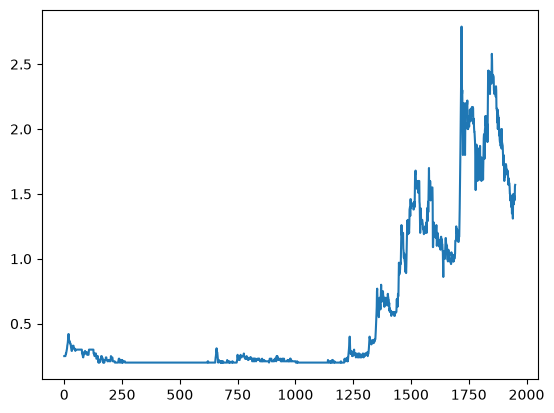

In [2]:
import matplotlib.pyplot as plt

plt.plot(veritaskap['close_price'])
plt.show()

In [4]:
veritaskap_end_month_df = (
    veritaskap
    .sort_values("date")
    .groupby(veritaskap["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

veritaskap_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,73226,VERITASKAP,2018-04-30,0.29,0.29,604676,2026-04-08T03:03:29.288658+00:00,4,2,2018
1,74993,VERITASKAP,2018-05-31,0.32,0.32,1099701,2026-04-08T03:04:33.384321+00:00,5,2,2018
2,76764,VERITASKAP,2018-06-29,0.29,0.29,1339878,2026-04-08T03:05:28.786725+00:00,6,2,2018
3,78844,VERITASKAP,2018-07-31,0.30,0.30,0,2026-04-08T03:06:33.766078+00:00,7,3,2018
4,80744,VERITASKAP,2018-08-31,0.29,0.29,101000,2026-04-08T03:07:34.108038+00:00,8,3,2018
...,...,...,...,...,...,...,...,...,...,...
95,35393,VERITASKAP,2026-03-31,2.09,2.09,22994409,2026-03-31T15:00:02.085058+00:00,3,1,2026
96,281218,VERITASKAP,2026-04-30,1.75,1.75,18590438,2026-04-30T15:00:02.170664+00:00,4,2,2026
97,284284,VERITASKAP,2026-05-29,1.65,1.65,14727689,2026-05-29T15:00:02.455558+00:00,5,2,2026
98,294212,VERITASKAP,2026-06-30,1.37,1.37,9095517,2026-06-30T15:10:03.08168+00:00,6,2,2026


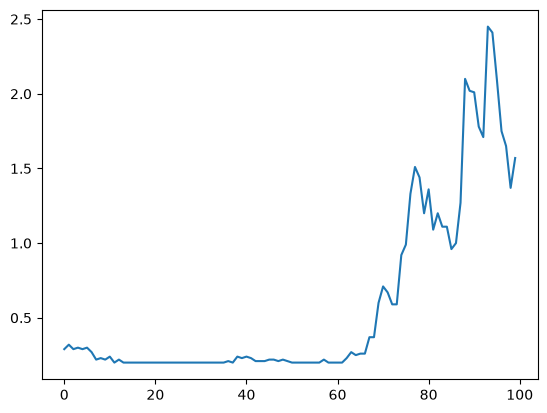

In [5]:
plt.plot(veritaskap_end_month_df['close_price'])
plt.show()

In [6]:
veritaskap_end_month_df['returns']=veritaskap_end_month_df['close_price'].pct_change()*100
veritaskap_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,73226,VERITASKAP,2018-04-30,0.29,0.29,604676,2026-04-08T03:03:29.288658+00:00,4,2,2018,NaN
1,74993,VERITASKAP,2018-05-31,0.32,0.32,1099701,2026-04-08T03:04:33.384321+00:00,5,2,2018,10.344828
2,76764,VERITASKAP,2018-06-29,0.29,0.29,1339878,2026-04-08T03:05:28.786725+00:00,6,2,2018,-9.375000
3,78844,VERITASKAP,2018-07-31,0.30,0.30,0,2026-04-08T03:06:33.766078+00:00,7,3,2018,3.448276
4,80744,VERITASKAP,2018-08-31,0.29,0.29,101000,2026-04-08T03:07:34.108038+00:00,8,3,2018,-3.333333
...,...,...,...,...,...,...,...,...,...,...,...
95,35393,VERITASKAP,2026-03-31,2.09,2.09,22994409,2026-03-31T15:00:02.085058+00:00,3,1,2026,-13.278008
96,281218,VERITASKAP,2026-04-30,1.75,1.75,18590438,2026-04-30T15:00:02.170664+00:00,4,2,2026,-16.267943
97,284284,VERITASKAP,2026-05-29,1.65,1.65,14727689,2026-05-29T15:00:02.455558+00:00,5,2,2026,-5.714286
98,294212,VERITASKAP,2026-06-30,1.37,1.37,9095517,2026-06-30T15:10:03.08168+00:00,6,2,2026,-16.969697


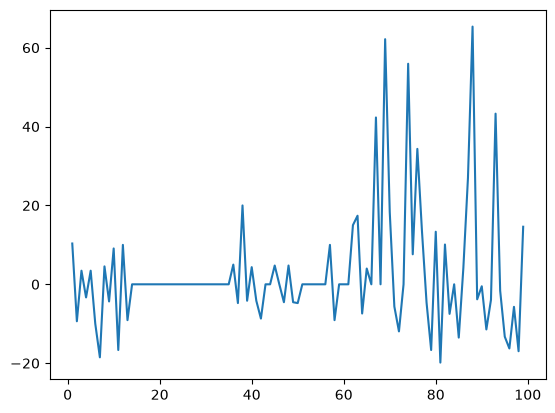

In [7]:
plt.plot(veritaskap_end_month_df['returns'])
plt.show()

In [8]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(veritaskap_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(np.float64(-6.1251204593440045), np.float64(8.666358714624873e-08), 2, 96, {'1%': np.float64(-3.5003788874873405), '5%': np.float64(-2.8921519665075235), '10%': np.float64(-2.5830997960069446)}, np.float64(716.85056319018))
stationary


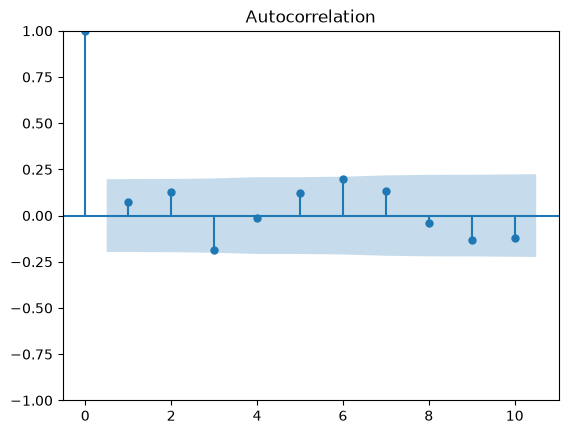

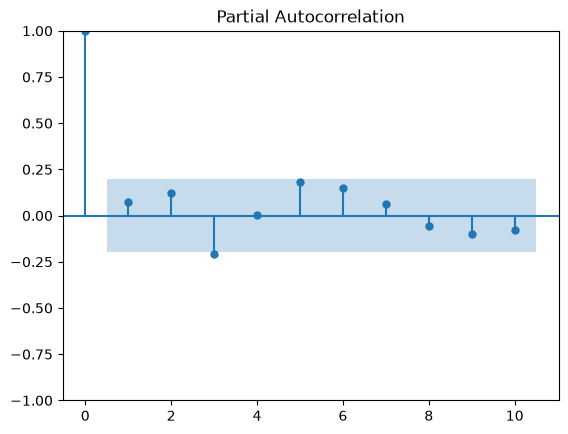

In [9]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(veritaskap_end_month_df['returns'].dropna(), lags=10)
plot_pacf(veritaskap_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [10]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=veritaskap_end_month_df['close_price'][:-10]
test=veritaskap_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -31.197951735899395]
[0, 0, 0, 0, 0, 1, -13.665472474470093]
[0, 0, 0, 0, 0, 2, -7.426203216066234]
[0, 0, 0, 0, 1, 0, -4.452464897630977]
[0, 0, 0, 0, 1, 1, -2.976008493090947]
[0, 0, 0, 0, 1, 2, -2.6536547150960175]
[0, 0, 0, 0, 2, 0, -1.3084060156740764]
[0, 0, 0, 0, 2, 1, -0.9484463164388974]
[0, 0, 0, 0, 2, 2, -1.04365091778291]
[0, 0, 0, 1, 0, 0, -5.886018160512191]
[0, 0, 0, 1, 0, 1, -4.467606437245668]
[0, 0, 0, 1, 0, 2, -4.137018260131141]
[0, 0, 0, 1, 1, 0, -1.9114462257952405]
[0, 0, 0, 1, 1, 1, -2.655063713870855]
[0, 0, 0, 1, 1, 2, -2.7541312066589767]
[0, 0, 0, 1, 2, 0, -0.8699402258709559]
[0, 0, 0, 1, 2, 1, -0.9818767163429283]
[0, 0, 0, 1, 2, 2, -1.1143316407843558]
[0, 0, 0, 2, 0, 0, -3.217632833318171]
[0, 0, 0, 2, 0, 1, -4.216812209902553]
[0, 0, 0, 2, 0, 2, -4.239244519417302]
[0, 0, 0, 2, 1, 0, -2.4248560774131374]
[0, 0, 0, 2, 1, 1, -2.705909060741775]
[0, 0, 0, 2, 1, 2, -2.8711124580838217]
[0, 0, 0, 2, 2, 0, -1.3084060132544866]
[0, 0, 0, 2, 

In [11]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
168,0,2,0,0,2,0,-112.042706
177,0,2,0,1,2,0,-56.235476
169,0,2,0,0,2,1,-53.373791
411,1,2,0,0,2,0,-47.811386
186,0,2,0,2,2,0,-46.457614
...,...,...,...,...,...,...,...
297,1,0,2,0,0,0,0.036280
522,2,0,1,1,0,0,0.038685
540,2,0,2,0,0,0,0.043510
270,1,0,1,0,0,0,0.068188


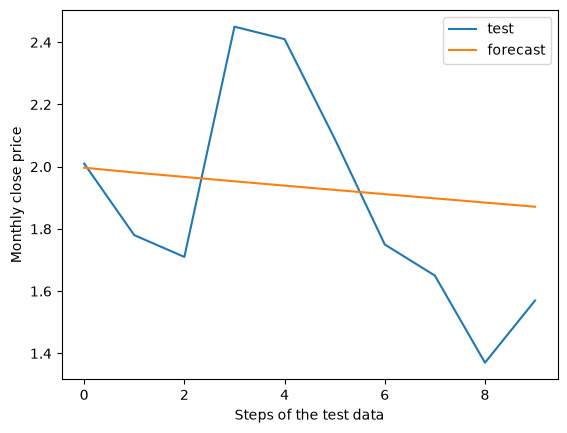

r2_score:  0.07578291883004806
rmse:  0.32340798205814636
description:  count    100.000000
mean       0.580400
std        0.608829
min        0.200000
25%        0.200000
50%        0.230000
75%        0.930000
max        2.450000
Name: close_price, dtype: float64


In [12]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

y_train=veritaskap_end_month_df['close_price'][:-10]
y_test=veritaskap_end_month_df['close_price'][-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(2,0,0), 
seasonal_order=(0,0,0,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', veritaskap_end_month_df.close_price.describe())

Its not capturing the variations properly. Lets try the returns

In [13]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=veritaskap_end_month_df['returns'].dropna()[:-10]
test=veritaskap_end_month_df['returns'].dropna()[-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -0.004715613210028113]
[0, 0, 0, 0, 0, 1, -0.06378329763875712]
[0, 0, 0, 0, 0, 2, -0.13016512065729957]
[0, 0, 0, 0, 1, 0, -0.8186917799907714]
[0, 0, 0, 0, 1, 1, -0.003749182019404218]
[0, 0, 0, 0, 1, 2, -0.15170229496282306]
[0, 0, 0, 0, 2, 0, -8.866218196455417]
[0, 0, 0, 0, 2, 1, -1.0182544301359622]
[0, 0, 0, 0, 2, 2, -0.45413674043786423]
[0, 0, 0, 1, 0, 0, -0.037117838894134]
[0, 0, 0, 1, 0, 1, 0.011421430003113908]
[0, 0, 0, 1, 0, 2, -0.03635145291450792]
[0, 0, 0, 1, 1, 0, -0.373747471164235]
[0, 0, 0, 1, 1, 1, -0.06652743779752268]
[0, 0, 0, 1, 1, 2, -0.12593859716070566]
[0, 0, 0, 1, 2, 0, -0.9013919991108115]
[0, 0, 0, 1, 2, 1, -0.6138180089451115]
[0, 0, 0, 1, 2, 2, -0.6217231587196668]
[0, 0, 0, 2, 0, 0, -0.07452476238129746]
[0, 0, 0, 2, 0, 1, -0.00997171832275856]
[0, 0, 0, 2, 0, 2, 0.042938298488501725]
[0, 0, 0, 2, 1, 0, -0.07471965538078362]
[0, 0, 0, 2, 1, 1, -0.036952570952273334]
[0, 0, 0, 2, 1, 2, -0.039511900646424625]
[0, 0, 0, 2, 2, 0, -0.9

In [14]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
167,0,2,0,0,1,2,-667.782530
163,0,2,0,0,0,1,-654.279236
171,0,2,0,1,0,0,-654.266749
172,0,2,0,1,0,1,-652.571146
164,0,2,0,0,0,2,-642.162738
...,...,...,...,...,...,...,...
211,0,2,1,2,1,1,0.163703
212,0,2,1,2,1,2,0.166999
94,0,1,0,1,1,1,0.167605
103,0,1,0,2,1,1,0.186229


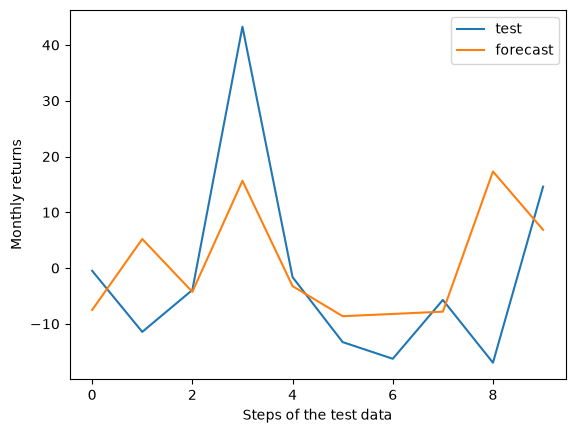

r2_score:  0.18913103818368338
rmse:  15.551659923113656
description:  count    99.000000
mean      2.640623
std      14.978351
min     -19.852941
25%      -4.257246
50%       0.000000
75%       4.257246
max      65.354331
Name: returns, dtype: float64


In [15]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

y_train=veritaskap_end_month_df['returns'].dropna()[:-10]
y_test=veritaskap_end_month_df['returns'].dropna()[-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(0,1,0), 
seasonal_order=(2,1,2,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly returns')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', veritaskap_end_month_df.returns.dropna().describe())

We will work with THIS
